<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/neural_networks/LSTM_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Sentiment analysis with recurrent neural networks (LSTM)

Images have a fixed size. Text does not: a review can have 10 words or 2,000, and the **order** of the words matters ("not good, just bad" versus "not bad, just good"). In this lab we classify IMDB movie reviews as **positive** or **negative** with a **recurrent neural network**. It reads the review one word at a time and keeps a memory, the hidden state, of what it has read so far.

We will also be honest about the results: for this particular task, simple models that ignore word order are very strong. Understanding **why** is as important as building the LSTM.

**Contents**

1. Setup
2. The data: IMDB reviews as sequences of word indices
3. A strong baseline that ignores word order
4. From text to tensors: truncation, padding, lengths
5. Word embeddings
6. Recurrent neural networks (RNN), from scratch
7. Backpropagation through time and vanishing gradients
8. The LSTM, from scratch
9. The model: Embedding → LSTM → linear
10. Training, with gradient clipping and early stopping
11. Evaluation and errors
12. Experiments: RNN vs LSTM vs GRU, bidirectional, which words to keep
13. Inside the models: word polarity, embeddings, reading a review word by word
14. Your own reviews
15. Summary and exercises

Theory: [`notes/neural_networks/04_rnn_lstm`](../../notes/neural_networks/04_rnn_lstm.ipynb) (embeddings, RNNs, BPTT, LSTM/GRU).

**Notation**

| Symbol | Meaning |
|---|---|
| $V = 10{,}000$ | vocabulary size (number of distinct tokens the model knows) |
| $T$ | sequence length after truncation and padding (200 here) |
| $d$ | embedding dimension (64) |
| $d_h$ | hidden state dimension (64) |
| $\mathbf{x}_t \in \mathbb{R}^d$ | embedding of the token at position $t$ |
| $\mathbf{h}_t \in \mathbb{R}^{d_h}$ | hidden state after reading tokens $1, \dots, t$ |
| $\mathbf{c}_t \in \mathbb{R}^{d_h}$ | LSTM cell state |
| $\sigma$, $\odot$ | sigmoid, element-wise product |

## 1. Setup

The lab only needs PyTorch, NumPy and scikit-learn. It trains several recurrent networks, which is much faster on a GPU (in Colab: *Runtime → Change runtime type → GPU*). Expect about 3 minutes on a GPU and 20 to 40 minutes on a CPU.

Earlier versions of this lab installed TensorFlow (about 600 MB) only to load the dataset. We now download the same two files directly.

In [1]:
import copy, json, os, re, time, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 2. The data: IMDB reviews as sequences of word indices

The [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/) (Maas et al., 2011) has 50,000 movie reviews: 25,000 for training and 25,000 for testing, half positive and half negative. We use the version distributed with Keras. Each review is already **tokenised**: lower-cased, punctuation removed, split into words, and each word replaced by its **frequency rank** in the corpus (1 = "the", the most frequent word, 2 = "and", and so on).

The file stores Python lists, so NumPy needs `allow_pickle=True`. Only do that with files from a source you trust; this one comes from the official Keras storage.

In [2]:
URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/"
cache = os.path.expanduser("~/.cache/imdb_keras")
os.makedirs(cache, exist_ok=True)
for fname in ["imdb.npz", "imdb_word_index.json"]:
    if not os.path.exists(os.path.join(cache, fname)):
        urllib.request.urlretrieve(URL + fname, os.path.join(cache, fname))

raw = np.load(os.path.join(cache, "imdb.npz"), allow_pickle=True)
word_rank = json.load(open(os.path.join(cache, "imdb_word_index.json")))    # word -> frequency rank (1 = most frequent)
print("train reviews:", len(raw["x_train"]), " test reviews:", len(raw["x_test"]))
print("distinct words in the corpus:", len(word_rank))
print("first review, as ranks:", raw["x_train"][0][:12], "...")

train reviews: 25000  test reviews: 25000
distinct words in the corpus: 88584


first review, as ranks: [23022, 309, 6, 3, 1069, 209, 9, 2175, 30, 1, 169, 55] ...


**Building the vocabulary.** A model cannot have an embedding for all 88,584 words, and most of them appear only a handful of times. We keep the $V = 10{,}000$ most frequent tokens and reserve four special indices at the start:

| Index | Token | Meaning |
|---|---|---|
| 0 | `<PAD>` | padding, to make all sequences in a batch the same length |
| 1 | `<START>` | marks the beginning of a review |
| 2 | `<UNK>` | any word outside the vocabulary |
| 3 | `<UNUSED>` | reserved |

Word of rank $r$ gets index $r + 3$, and every index $\ge V$ becomes `<UNK>`. This is the same convention as `keras.datasets.imdb.load_data(num_words=10000)`.

**Three sets.** The raw file is sorted by label, so we shuffle it. We hold out 5,000 training reviews as a **validation set** for all model choices (architecture, epochs), and keep the 25,000 test reviews for the final evaluation only.

In [3]:
V = 10_000
PAD, START, UNK = 0, 1, 2
word_index = {w: r + 3 for w, r in word_rank.items()}
word_index.update({"<PAD>": PAD, "<START>": START, "<UNK>": UNK, "<UNUSED>": 3})
index_word = {i: w for w, i in word_index.items()}

def encode_ranks(ranks):
    """Frequency ranks -> token indices in [0, V), with <START> first and rare words as <UNK>."""
    return np.array([START] + [r + 3 if r + 3 < V else UNK for r in ranks], dtype=np.int64)

def decode(ids):
    return " ".join(index_word.get(int(i), "?") for i in ids if int(i) != PAD)

rng = np.random.default_rng(0)
perm = rng.permutation(len(raw["x_train"]))
seqs_all = [encode_ranks(r) for r in raw["x_train"][perm]]
labels_all = raw["y_train"][perm]
seqs_val, y_val = seqs_all[:5000], labels_all[:5000]
seqs_tr, y_tr = seqs_all[5000:], labels_all[5000:]
seqs_te, y_te = [encode_ranks(r) for r in raw["x_test"]], raw["y_test"]
class_names = ["Negative", "Positive"]

print(f"train {len(seqs_tr)}, validation {len(seqs_val)}, test {len(seqs_te)}")
print(f"fraction positive: train {y_tr.mean():.3f}, validation {y_val.mean():.3f}, test {y_te.mean():.3f}")
print("\nexample review, as indices:", seqs_tr[0][:15], "...")
print("decoded:", decode(seqs_tr[0])[:600], "...")
print("label:", class_names[y_tr[0]])

train 20000, validation 5000, test 25000
fraction positive: train 0.500, validation 0.501, test 0.500

example review, as indices: [   1 1100    5 4434  185 4545    2    6    2    2    5 5755  239   34
    2] ...
decoded: <START> bored and unhappy young babe <UNK> a <UNK> <UNK> and vibrant performance by <UNK> brunette <UNK> erika anderson feels trapped in a stale and <UNK> marriage to failed poet and decent yet dull businessman <UNK> martin a solid and credible portrayal by judge <UNK> <UNK> has a <UNK> <UNK> <UNK> with sleazy and arrogant artist johnny collins deliciously played to the slimy <UNK> by nicolas cage can the relationship between <UNK> and <UNK> be <UNK> or is everything going to fall apart and go to seed director sam <UNK> and screenwriter <UNK> <UNK> lay on the <UNK> soap opera style <UNK> somet ...
label: Positive


You will see `br` in many reviews: the original text contained HTML line breaks `<br />`, which the tokeniser turned into the word "br". Real data is always a little dirty.

**How long are the reviews, and how much of the text does the vocabulary cover?**

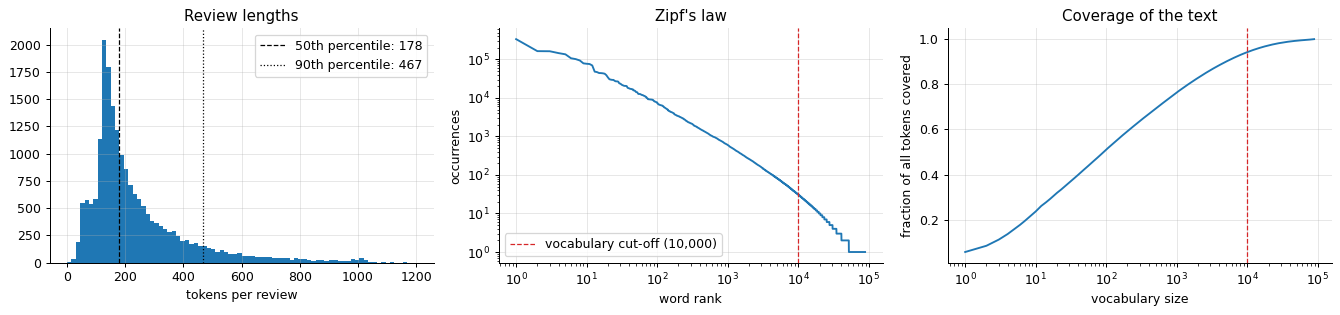

median length 178 tokens, mean 239, max 2494
with V = 10,000: 94.3% of all training tokens are in the vocabulary


In [4]:
lengths = np.array([len(s) for s in seqs_tr])
counts = np.bincount(np.concatenate(seqs_tr), minlength=V)
unk_frac = counts[UNK] / counts.sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(lengths, bins=80, range=(0, 1200))
for q, ls in [(50, "--"), (90, ":")]:
    axes[0].axvline(np.percentile(lengths, q), color="k", ls=ls, lw=1, label=f"{q}th percentile: {np.percentile(lengths, q):.0f}")
axes[0].set_xlabel("tokens per review"); axes[0].set_title("Review lengths"); axes[0].legend()

freq = np.sort(np.array(list(np.bincount(np.concatenate([r for r in raw["x_train"]])))[1:]))[::-1]
axes[1].loglog(np.arange(1, len(freq) + 1), freq)
axes[1].axvline(V, color="C3", ls="--", lw=1, label=f"vocabulary cut-off ({V:,})")
axes[1].set_xlabel("word rank"); axes[1].set_ylabel("occurrences"); axes[1].set_title("Zipf's law"); axes[1].legend()

cover = np.cumsum(freq) / freq.sum()
axes[2].semilogx(np.arange(1, len(freq) + 1), cover)
axes[2].axvline(V, color="C3", ls="--", lw=1)
axes[2].set_xlabel("vocabulary size"); axes[2].set_ylabel("fraction of all tokens covered"); axes[2].set_title("Coverage of the text")
plt.tight_layout(); plt.show()
print(f"median length {np.median(lengths):.0f} tokens, mean {lengths.mean():.0f}, max {lengths.max()}")
print(f"with V = {V:,}: {1 - unk_frac:.1%} of all training tokens are in the vocabulary")

- The lengths are very skewed: most reviews have 100 to 300 tokens, a few have more than 1,000.
- Word frequencies follow **Zipf's law**: frequency is roughly proportional to $1/\text{rank}$, a straight line on a log-log plot. A few words are extremely common and a long tail is very rare.
- Because of that, 10,000 words (11% of the distinct words) cover about 94% of all the text. The rare words we drop are mostly names and typos, which become `<UNK>` (you can see several in the decoded review above).

## 3. A strong baseline that ignores word order

Before building an LSTM, we should know what a simple model achieves. The classic text baseline is **bag of words**: represent each review by how often each vocabulary word appears, throwing away the order entirely, and fit a logistic regression. We use the **TF-IDF** weighting, which down-weights words that appear in almost every review ("the", "movie") and up-weights distinctive ones.

$$
\text{tfidf}(w, \text{review}) = \underbrace{\text{count of } w \text{ in the review}}_{\text{term frequency}} \times \underbrace{\log\frac{1 + N}{1 + \text{number of reviews containing } w}}_{\text{inverse document frequency}}
$$

(scikit-learn adds 1 to the logarithm and normalises each review's vector to unit length.)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(analyzer=lambda ids: ids.tolist())     # our reviews are already token lists
A_tr = tfidf.fit_transform(seqs_tr)
A_val = tfidf.transform(seqs_val)
logreg = LogisticRegression(C=5, max_iter=2000).fit(A_tr, y_tr)
acc_bow_val = logreg.score(A_val, y_val)
print(f"TF-IDF + logistic regression: {A_tr.shape[1]:,} features, validation accuracy {acc_bow_val:.4f}")

coef = logreg.coef_[0]
vocab = np.array(tfidf.get_feature_names_out())
order = np.argsort(coef)
print("\nmost negative words:", ", ".join(index_word[int(vocab[i])] for i in order[:15]))
print("most positive words:", ", ".join(index_word[int(vocab[i])] for i in order[::-1][:15]))

TF-IDF + logistic regression: 9,998 features, validation accuracy 0.8956

most negative words: worst, awful, waste, bad, boring, disappointment, poorly, terrible, horrible, worse, dull, mess, fails, nothing, poor
most positive words: 7, great, excellent, perfect, best, 8, wonderful, today, amazing, highly, fun, favorite, wonderfully, loved, enjoyed


Almost 90% without knowing anything about word order. The weights make sense: "worst", "waste" and "awful" are strong negative evidence, "excellent", "perfect" and "7" (as in "7/10") positive. **Movie-review sentiment is mostly carried by which words appear.** Keep this number in mind: a sequence model has to earn its extra complexity.

## 4. From text to tensors: truncation, padding, lengths

To train in batches, all sequences in a batch must have the same length $T$.

**Truncation.** Reviews longer than $T$ are cut. Which part to keep is a real choice: the original lab kept the **first** 100 tokens. Reviewers often state their verdict at the end ("... overall, 8/10"), so we keep the **last** $T = 200$ tokens. Section 12 compares both options.

**Padding.** Shorter reviews are filled with `<PAD>` (index 0) up to length $T$. We pad at the **end** and also store each review's true **length**. The model will use the lengths to ignore the padding (section 9). Without that, a recurrent network would keep updating its memory on the padding tokens, and the final state would describe "review followed by many pads".

The result is a tensor of shape $(N, T)$ of token indices, a tensor of $N$ lengths and a tensor of $N$ labels.

In [6]:
T = 200

def to_tensors(seqs, labels, T=T, keep="last"):
    X = np.zeros((len(seqs), T), dtype=np.int64)            # filled with <PAD> = 0
    L = np.zeros(len(seqs), dtype=np.int64)
    for i, s in enumerate(seqs):
        s = s[-T:] if keep == "last" else s[:T]             # truncate
        X[i, :len(s)] = s                                    # pad at the end
        L[i] = len(s)
    return torch.tensor(X), torch.tensor(L), torch.tensor(labels, dtype=torch.float32)

X_tr, L_tr, Y_tr = to_tensors(seqs_tr, y_tr)
X_val, L_val, Y_val = to_tensors(seqs_val, y_val)
X_te, L_te, Y_te = to_tensors(seqs_te, y_te)
print("X_tr:", tuple(X_tr.shape), X_tr.dtype, " L_tr:", tuple(L_tr.shape), " Y_tr:", tuple(Y_tr.shape))
print(f"reviews truncated to {T}: {(lengths > T).mean():.1%}")
i_short = int(np.argmin(lengths))
print(f"\nshortest training review ({lengths[i_short]} tokens) as a padded row:\n", X_tr[i_short][:30].tolist(), "...")

train_loader = DataLoader(TensorDataset(X_tr, L_tr, Y_tr), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, L_val, Y_val), batch_size=500)
test_loader = DataLoader(TensorDataset(X_te, L_te, Y_te), batch_size=500)

X_tr: (20000, 200) torch.int64  L_tr: (20000,)  Y_tr: (20000,)
reviews truncated to 200: 42.8%

shortest training review (11 tokens) as a padded row:
 [1, 14, 20, 9, 394, 21, 12, 47, 49, 52, 302, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...


## 5. Word embeddings

A token index such as 1,047 is just a name. Its numerical value means nothing: word 1,047 is not "bigger" than word 1,046. The textbook fix is **one-hot encoding**, a vector $\mathbf{e}_k \in \mathbb{R}^V$ with a 1 at position $k$. It is huge ($V = 10{,}000$ dimensions) and says that every word is equally different from every other word.

An **embedding layer** stores a matrix $\mathbf{E} \in \mathbb{R}^{V \times d}$ and maps token $k$ to row $k$:

$$
\mathbf{x} = \mathbf{E}[k] = \mathbf{e}_k^\top \mathbf{E} \in \mathbb{R}^d .
$$

So an embedding is exactly a linear layer applied to a one-hot vector, implemented as a table lookup instead of a multiplication by a vector of zeros. The rows are **learned** by backpropagation like any other weights. Words that play similar roles for the task end up with similar vectors (section 13).

In PyTorch, `nn.Embedding(V, d, padding_idx=0)` holds $\mathbf{E}$. `padding_idx=0` keeps the `<PAD>` row at zero and never updates it. It has $V \cdot d = 640{,}000$ parameters for $d = 64$: the embedding table is the largest part of our model.

In [7]:
emb = nn.Embedding(V, 64, padding_idx=PAD)
tokens = torch.tensor([[START, word_index["great"], word_index["movie"], PAD]])
out = emb(tokens)
print("tokens:", tokens.shape, "-> embeddings:", out.shape, "  (batch, time, d)")
print("<PAD> embedding is zero:", bool((out[0, 3] == 0).all()))

one_hot = F.one_hot(torch.tensor(word_index["great"]), V).float()
print("one-hot @ E equals the lookup:", torch.allclose(one_hot @ emb.weight, emb(torch.tensor(word_index["great"]))))

tokens: torch.Size([1, 4]) -> embeddings: torch.Size([1, 4, 64])   (batch, time, d)
<PAD> embedding is zero: True
one-hot @ E equals the lookup: True


## 6. Recurrent neural networks (RNN), from scratch

A recurrent network reads the sequence $\mathbf{x}_1, \dots, \mathbf{x}_T$ one step at a time and updates a hidden state:

$$
\boxed{\mathbf{h}_t = \tanh\big(\mathbf{W}_{xh}\,\mathbf{x}_t + \mathbf{W}_{hh}\,\mathbf{h}_{t-1} + \mathbf{b}\big)}, \qquad \mathbf{h}_0 = \mathbf{0} .
$$

- $\mathbf{h}_t \in \mathbb{R}^{d_h}$ is a **summary of everything read so far**, a fixed-size memory whatever the length.
- The **same** weights $\mathbf{W}_{xh} \in \mathbb{R}^{d_h \times d}$ and $\mathbf{W}_{hh} \in \mathbb{R}^{d_h \times d_h}$ are used at every step: weight sharing over time, just as a CNN shares weights over space. The model therefore works for any length.
- For classification we use the last state $\mathbf{h}_T$ as the representation of the whole review and put a logistic regression on top: $\hat{y} = \sigma(\mathbf{w}^\top\mathbf{h}_T + b)$.

"Unrolling" the loop over time gives a very deep feedforward network, $T$ layers deep, with shared weights:

$$
\mathbf{h}_0 \xrightarrow{\;\mathbf{x}_1\;} \mathbf{h}_1 \xrightarrow{\;\mathbf{x}_2\;} \mathbf{h}_2 \xrightarrow{\;\mathbf{x}_3\;} \cdots \xrightarrow{\;\mathbf{x}_T\;} \mathbf{h}_T \longrightarrow \hat{y}
$$

We write the loop by hand and check it against `nn.RNN`. PyTorch stores the weights as `weight_ih_l0` ($\mathbf{W}_{xh}$), `weight_hh_l0` ($\mathbf{W}_{hh}$), and two bias vectors that are simply added.

In [8]:
torch.manual_seed(0)
rnn = nn.RNN(input_size=5, hidden_size=3, batch_first=True)
x = torch.randn(2, 7, 5)                                    # batch of 2 sequences, 7 steps, 5 features

def rnn_by_hand(x, rnn):
    W_xh, W_hh = rnn.weight_ih_l0, rnn.weight_hh_l0
    b = rnn.bias_ih_l0 + rnn.bias_hh_l0
    h = torch.zeros(x.shape[0], W_hh.shape[0])
    outputs = []
    for t in range(x.shape[1]):                             # one step at a time
        h = torch.tanh(x[:, t] @ W_xh.T + h @ W_hh.T + b)
        outputs.append(h)
    return torch.stack(outputs, dim=1), h

out_hand, h_hand = rnn_by_hand(x, rnn)
out_torch, h_torch = rnn(x)
print("outputs (all h_t):", tuple(out_torch.shape), " final state h_T:", tuple(h_torch.shape), "(layers, batch, d_h)")
print("max |by hand - nn.RNN|:", (out_hand - out_torch).abs().max().item())

outputs (all h_t): (2, 7, 3)  final state h_T: (1, 2, 3) (layers, batch, d_h)
max |by hand - nn.RNN|: 5.960464477539063e-08


`nn.RNN` returns two things: the outputs $\mathbf{h}_1, \dots, \mathbf{h}_T$ for every step, shape $(B, T, d_h)$ with `batch_first=True`, and the final state $\mathbf{h}_T$ with shape $(\text{layers}, B, d_h)$.

## 7. Backpropagation through time and vanishing gradients

Training an unrolled RNN is ordinary backpropagation on the unrolled graph, called **backpropagation through time** (BPTT). The gradient of the loss with respect to an early state goes through every later step:

$$
\frac{\partial J}{\partial \mathbf{h}_t} = \frac{\partial J}{\partial \mathbf{h}_T}\prod_{k=t+1}^{T}\frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}},
\qquad
\frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}} = \text{diag}\big(1 - \mathbf{h}_k^2\big)\,\mathbf{W}_{hh} .
$$

(The second formula is the chain rule on $\mathbf{h}_k = \tanh(\cdot)$, using $\tanh' = 1 - \tanh^2$.) Taking norms, $\lVert \text{diag}(1 - \mathbf{h}_k^2) \rVert \le 1$, so

$$
\left\lVert \frac{\partial J}{\partial \mathbf{h}_t} \right\rVert \le \left\lVert \frac{\partial J}{\partial \mathbf{h}_T} \right\rVert \cdot \lVert \mathbf{W}_{hh} \rVert^{\,T - t} .
$$

- If $\lVert \mathbf{W}_{hh} \rVert < 1$, the gradient shrinks **exponentially** with the distance $T - t$: the **vanishing gradient**. A word 50 steps back has essentially no influence on the weight update, so the RNN cannot learn long-range dependencies.
- If the factors are larger than 1, the gradient can grow exponentially: **exploding gradients**, which make training unstable. The standard fix is **gradient clipping**: if $\lVert \mathbf{g} \rVert > \tau$, rescale it to $\tau\,\mathbf{g}/\lVert\mathbf{g}\rVert$. It keeps the direction and limits the step.

Section 12 shows the practical consequence: a plain RNN is much worse than an LSTM on 200-token reviews.

## 8. The LSTM, from scratch

The **Long Short-Term Memory** (Hochreiter and Schmidhuber, 1997) adds a second state, the **cell state** $\mathbf{c}_t$, and three **gates**: vectors of numbers between 0 and 1 that decide, element by element, how much information flows. With $[\mathbf{h}_{t-1}, \mathbf{x}_t]$ the two vectors stacked:

$$
\begin{aligned}
\mathbf{i}_t &= \sigma(\mathbf{W}_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i) &&\text{input gate: how much new content to write}\\
\mathbf{f}_t &= \sigma(\mathbf{W}_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f) &&\text{forget gate: how much old memory to keep}\\
\mathbf{g}_t &= \tanh(\mathbf{W}_g [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_g) &&\text{candidate content}\\
\mathbf{o}_t &= \sigma(\mathbf{W}_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o) &&\text{output gate: how much memory to show}\\
\mathbf{c}_t &= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \mathbf{g}_t &&\text{update the memory}\\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t) &&\text{new hidden state}
\end{aligned}
$$

**Why the gradient survives.** The cell state is updated **additively**. Following the direct path through the cell,

$$
\frac{\partial \mathbf{c}_t}{\partial \mathbf{c}_{t-1}} = \text{diag}(\mathbf{f}_t)
\qquad\Longrightarrow\qquad
\frac{\partial \mathbf{c}_T}{\partial \mathbf{c}_t} = \text{diag}\Big(\prod_{k=t+1}^{T}\mathbf{f}_k\Big) \quad\text{(along this path)} .
$$

There is no weight matrix and no $\tanh'$ in this product, only the forget gates. When the network wants to remember something, it can set $\mathbf{f}_k \approx 1$ and the gradient flows back almost unchanged over many steps. In a plain RNN the memory is rewritten through $\mathbf{W}_{hh}$ and $\tanh$ at every step, and there is no way to keep the gradient from shrinking. (The gates themselves depend on $\mathbf{h}_{t-1}$, which adds other gradient paths, but the direct cell path is what makes long memory learnable.) A common trick is to initialise the forget-gate bias to 1, so that the LSTM starts out remembering.

**Parameters.** Each of the four blocks has a $d_h \times (d_h + d)$ matrix and a bias, so an LSTM layer has $4\,(d_h(d_h + d) + d_h)$ parameters, four times a plain RNN. PyTorch keeps two bias vectors per block, so it reports $4\,(d_h(d_h + d) + 2d_h)$.

**GRU.** The Gated Recurrent Unit (Cho et al., 2014) is a simpler variant with two gates and no separate cell state, three blocks instead of four. It often performs similarly.

We implement one LSTM step by hand and compare it with `nn.LSTM`. PyTorch stacks the four blocks in the order **i, f, g, o** in `weight_ih_l0` (applied to $\mathbf{x}_t$) and `weight_hh_l0` (applied to $\mathbf{h}_{t-1}$).

In [9]:
torch.manual_seed(0)
d, dh = 5, 3
lstm = nn.LSTM(d, dh, batch_first=True)
x = torch.randn(2, 7, d)

def lstm_by_hand(x, lstm):
    Wx, Wh, b = lstm.weight_ih_l0, lstm.weight_hh_l0, lstm.bias_ih_l0 + lstm.bias_hh_l0
    B, dh = x.shape[0], Wh.shape[1]
    h, c = torch.zeros(B, dh), torch.zeros(B, dh)
    for t in range(x.shape[1]):
        z = x[:, t] @ Wx.T + h @ Wh.T + b                   # (B, 4 dh): all four blocks at once
        i, f, g, o = z.chunk(4, dim=1)                      # PyTorch order: input, forget, candidate, output
        i, f, g, o = torch.sigmoid(i), torch.sigmoid(f), torch.tanh(g), torch.sigmoid(o)
        c = f * c + i * g                                   # additive memory update
        h = o * torch.tanh(c)
    return h, c

h_hand, c_hand = lstm_by_hand(x, lstm)
_, (h_t, c_t) = lstm(x)
print("max |h by hand - nn.LSTM|:", (h_hand - h_t[0]).abs().max().item())
print("max |c by hand - nn.LSTM|:", (c_hand - c_t[0]).abs().max().item())
for name, p in lstm.named_parameters():
    print(f"  {name:<14} {tuple(p.shape)}")
n = sum(p.numel() for p in nn.LSTM(64, 64).parameters())
print(f"nn.LSTM(64, 64) has {n:,} parameters = 4 * (64 * (64 + 64) + 2 * 64)")

max |h by hand - nn.LSTM|: 8.940696716308594e-08
max |c by hand - nn.LSTM|: 1.7881393432617188e-07
  weight_ih_l0   (12, 5)
  weight_hh_l0   (12, 3)
  bias_ih_l0     (12,)
  bias_hh_l0     (12,)
nn.LSTM(64, 64) has 33,280 parameters = 4 * (64 * (64 + 64) + 2 * 64)


## 9. The model: Embedding → LSTM → linear

$$
\text{token indices } (B, T) \xrightarrow{\text{Embedding}} (B, T, d) \xrightarrow{\text{LSTM}} \mathbf{h}_{\text{last}} \;(B, d_h) \xrightarrow{\text{Dropout}} \xrightarrow{\text{Linear}} \text{logit } (B,)
$$

Three details matter:

1. **Use the state after the last real token.** The original lab took the LSTM output at position $T$. For a review shorter than $T$, padded at the end, that is the state after reading all the padding, and the LSTM has been updating its memory on `<PAD>` tokens. We give the true lengths to **`pack_padded_sequence`**: the LSTM then stops at each review's real end, and the returned final state $\mathbf{h}_{\text{last}}$ is the right one. (Padding at the start instead is another common fix.)
2. **Return a logit** and use `nn.BCEWithLogitsLoss`, as in the MLP labs, instead of a sigmoid followed by `nn.BCELoss`.
3. `padding_idx=0` in the embedding.

The class also supports a plain RNN, a GRU and a bidirectional variant, for the experiments of section 12. A **bidirectional** network runs a second recurrent network from the end of the review to the start and concatenates both final states. Each word is then seen with its left and its right context.

In [10]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size=V, embedding_dim=64, hidden_dim=64, cell="lstm", bidirectional=False, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD)
        rnn_class = {"lstm": nn.LSTM, "gru": nn.GRU, "rnn": nn.RNN}[cell]
        self.rnn = rnn_class(embedding_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        self.bidirectional = bidirectional
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), 1)

    def forward(self, x, lengths):
        e = self.embedding(x)                                          # (B, T, d)
        packed = pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h = self.rnn(packed)                                        # LSTM returns (h, c); others return h
        h = h[0] if isinstance(h, tuple) else h                        # h: (directions, B, d_h)
        h = torch.cat([h[-2], h[-1]], dim=1) if self.bidirectional else h[-1]
        return self.fc(self.dropout(h)).squeeze(1)                     # (B,) logits

model = SentimentRNN()
print(model)
for name, mod in [("embedding", model.embedding), ("lstm", model.rnn), ("fc", model.fc)]:
    print(f"  {name:<10} {sum(p.numel() for p in mod.parameters()):>9,} parameters")
print(f"  {'total':<10} {sum(p.numel() for p in model.parameters()):>9,}")

SentimentRNN(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (rnn): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
  embedding    640,000 parameters
  lstm          33,280 parameters
  fc                65 parameters
  total        673,345


95% of the parameters are in the embedding table. The recurrent part that reads the sequence is small.

## 10. Training, with gradient clipping and early stopping

The loop is the one from the previous labs, with two additions for recurrent networks:
- the batch contains `(tokens, lengths, labels)`, and the model receives the lengths;
- **gradient clipping** (`nn.utils.clip_grad_norm_`, section 7) limits the norm of the gradient to 1 before each step, which protects against the occasional exploding gradient.

`fit` evaluates on the validation set after every epoch and restores the weights of the epoch with the lowest validation loss (**early stopping**). The `evaluate` helper returns the loss, the accuracy and the predicted probabilities.

In [11]:
criterion = nn.BCEWithLogitsLoss()

def evaluate(model, loader):
    model.eval()
    probs, total = [], 0.0
    with torch.no_grad():
        for xb, lb, yb in loader:
            logits = model(xb.to(device), lb)
            total += criterion(logits, yb.to(device)).item() * len(yb)
            probs.append(torch.sigmoid(logits).cpu())
    probs = torch.cat(probs)
    y = torch.cat([yb for _, _, yb in loader])
    return total / len(y), ((probs > 0.5).float() == y).float().mean().item(), probs.numpy()

def fit(model, train_loader, val_loader, epochs=8, lr=2e-3, clip=1.0, verbose=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")}
    best = (float("inf"), None, 0)
    for epoch in range(epochs):
        model.train()
        tot, correct, n, t0 = 0.0, 0, 0, time.time()
        for xb, lb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb, lb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)       # gradient clipping
            optimizer.step()
            tot += loss.item() * len(yb); correct += ((logits > 0).float() == yb).sum().item(); n += len(yb)
        vl, va, _ = evaluate(model, val_loader)
        for k, v in zip(hist, (tot / n, correct / n, vl, va)): hist[k].append(v)
        if vl < best[0]:
            best = (vl, copy.deepcopy(model.state_dict()), epoch)
        if verbose:
            print(f"epoch {epoch + 1}  train loss {tot / n:.4f} acc {correct / n:.4f}   val loss {vl:.4f} acc {va:.4f}   ({time.time() - t0:.1f}s)")
    model.load_state_dict(best[1])
    hist["best_epoch"] = best[2]
    if verbose:
        print(f"-> restored epoch {best[2] + 1}: val loss {best[0]:.4f}, val acc {hist['val_acc'][best[2]]:.4f}")
    return hist

torch.manual_seed(0)
lstm_model = SentimentRNN(cell="lstm")
hist_lstm = fit(lstm_model, train_loader, val_loader)

epoch 1  train loss 0.5915 acc 0.6700   val loss 0.5073 acc 0.7488   (2.3s)


epoch 2  train loss 0.4147 acc 0.8194   val loss 0.5176 acc 0.7898   (1.9s)


epoch 3  train loss 0.3215 acc 0.8699   val loss 0.4597 acc 0.8158   (2.0s)


epoch 4  train loss 0.2613 acc 0.9008   val loss 0.3314 acc 0.8672   (1.9s)


epoch 5  train loss 0.2007 acc 0.9252   val loss 0.3257 acc 0.8704   (1.9s)


epoch 6  train loss 0.1583 acc 0.9437   val loss 0.3375 acc 0.8720   (1.9s)


epoch 7  train loss 0.1217 acc 0.9585   val loss 0.4104 acc 0.8732   (1.9s)


epoch 8  train loss 0.0871 acc 0.9718   val loss 0.4128 acc 0.8662   (1.9s)
-> restored epoch 5: val loss 0.3257, val acc 0.8704


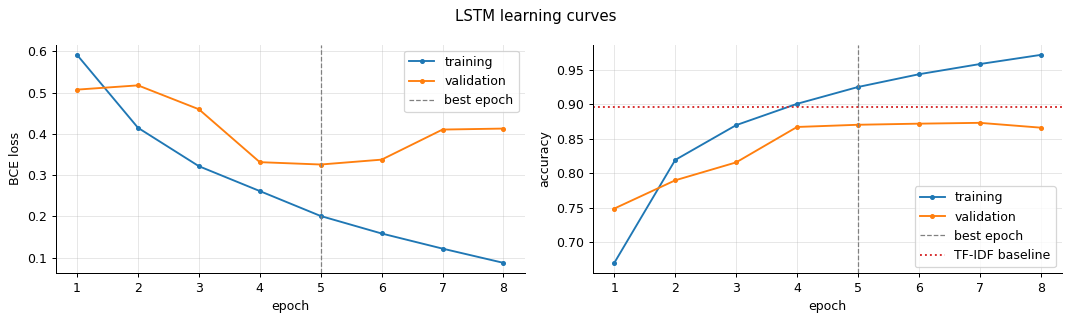

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
ep = np.arange(1, len(hist_lstm["train_loss"]) + 1)
for ax, key, name in [(axes[0], "loss", "BCE loss"), (axes[1], "acc", "accuracy")]:
    ax.plot(ep, hist_lstm[f"train_{key}"], "o-", ms=3, label="training")
    ax.plot(ep, hist_lstm[f"val_{key}"], "o-", ms=3, label="validation")
    ax.axvline(hist_lstm["best_epoch"] + 1, color="gray", ls="--", lw=1, label="best epoch")
    ax.set_xlabel("epoch"); ax.set_ylabel(name); ax.legend()
axes[1].axhline(acc_bow_val, color="C3", ls=":", label="TF-IDF baseline"); axes[1].legend()
fig.suptitle("LSTM learning curves"); plt.tight_layout(); plt.show()

The LSTM overfits quickly: after a few epochs the training accuracy keeps climbing while the validation loss goes up. With 640,000 embedding parameters and 20,000 reviews, it can memorise the training set. Early stopping keeps the best epoch.

**Why the lengths matter.** Let us check point 1 of section 9 on the trained model: feed a short review padded at the end, once with the true length (packed) and once pretending it has length $T$ (the LSTM also reads the padding).

In [13]:
short = [i for i in range(len(seqs_val)) if len(seqs_val[i]) < 60][:200]
xb, lb = X_val[short].to(device), L_val[short]
lstm_model.eval()
with torch.no_grad():
    p_packed = torch.sigmoid(lstm_model(xb, lb)).cpu()
    p_reads_pads = torch.sigmoid(lstm_model(xb, torch.full_like(lb, T))).cpu()
yb = Y_val[short]
print(f"{len(short)} short validation reviews (< 60 tokens, so more than 140 pads each)")
print(f"accuracy using the true lengths:       {((p_packed > 0.5).float() == yb).float().mean():.3f}")
print(f"accuracy if the LSTM also reads the pads: {((p_reads_pads > 0.5).float() == yb).float().mean():.3f}")
print(f"mean |change in probability|: {(p_packed - p_reads_pads).abs().mean():.3f}")

174 short validation reviews (< 60 tokens, so more than 140 pads each)
accuracy using the true lengths:       0.868
accuracy if the LSTM also reads the pads: 0.845
mean |change in probability|: 0.087


After 140 or more padding steps the memory has drifted: the probabilities change noticeably and the accuracy on these reviews drops. With more padding, or with a model trained without packing, the effect is larger. Handling variable lengths correctly is not a detail.

## 11. Evaluation and errors

All choices are made, so we evaluate once on the 25,000 test reviews. We compare with the TF-IDF baseline on the same test set.

In [14]:
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

test_loss, test_acc, p_te = evaluate(lstm_model, test_loader)
acc_bow_te = logreg.score(tfidf.transform(seqs_te), y_te)
print(f"LSTM          test accuracy {test_acc:.4f}   ROC AUC {roc_auc_score(y_te, p_te):.4f}")
print(f"TF-IDF + LR   test accuracy {acc_bow_te:.4f}   ROC AUC {roc_auc_score(y_te, logreg.predict_proba(tfidf.transform(seqs_te))[:, 1]):.4f}\n")
pred_te = (p_te > 0.5).astype(int)
print(classification_report(y_te, pred_te, target_names=class_names, digits=3))
print("confusion matrix (rows = true, columns = predicted):\n", confusion_matrix(y_te, pred_te))

LSTM          test accuracy 0.8670   ROC AUC 0.9343


TF-IDF + LR   test accuracy 0.8833   ROC AUC 0.9534

              precision    recall  f1-score   support

    Negative      0.867     0.867     0.867     12500
    Positive      0.867     0.867     0.867     12500

    accuracy                          0.867     25000
   macro avg      0.867     0.867     0.867     25000
weighted avg      0.867     0.867     0.867     25000

confusion matrix (rows = true, columns = predicted):
 [[10835  1665]
 [ 1660 10840]]


Two classes, balanced: accuracy, precision and recall all tell a similar story. The **ROC AUC** (area under the ROC curve, from the logistic regression notes) measures how well the probabilities **rank** positive reviews above negative ones, independently of the 0.5 threshold.

**Accuracy by review length.** Does the model do worse on long reviews, where it only sees the last 200 tokens, or on very short ones, where there is little evidence?

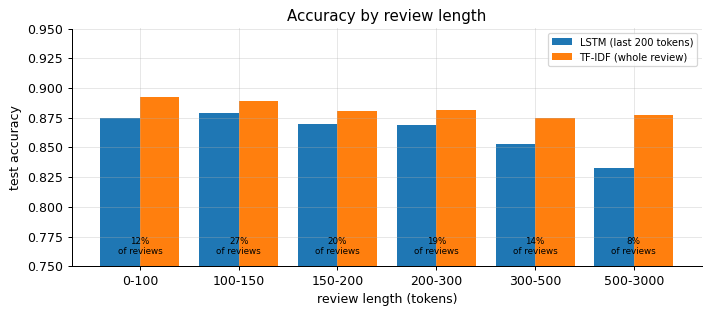

In [15]:
len_te = np.array([len(s) for s in seqs_te])
bins = [0, 100, 150, 200, 300, 500, 3000]
p_bow_te = logreg.predict_proba(tfidf.transform(seqs_te))[:, 1]
centers, acc_l, acc_b, share = [], [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (len_te >= lo) & (len_te < hi)
    centers.append(f"{lo}-{hi}"); share.append(m.mean())
    acc_l.append(np.mean(pred_te[m] == y_te[m])); acc_b.append(np.mean((p_bow_te[m] > 0.5) == y_te[m]))
xs = np.arange(len(centers))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(xs - 0.2, acc_l, 0.4, label="LSTM (last 200 tokens)"); ax.bar(xs + 0.2, acc_b, 0.4, label="TF-IDF (whole review)")
for xi, s in zip(xs, share): ax.text(xi, 0.76, f"{s:.0%}\nof reviews", ha="center", fontsize=7)
ax.set_xticks(xs); ax.set_xticklabels(centers); ax.set_ylim(0.75, 0.95)
ax.set_xlabel("review length (tokens)"); ax.set_ylabel("test accuracy"); ax.legend(fontsize=8)
ax.set_title("Accuracy by review length"); plt.tight_layout(); plt.show()

Look at the longest reviews: the LSTM only reads their last 200 tokens, while the bag-of-words model uses the whole text. Truncation is a real cost.

**The most confident mistakes.** Reading errors is the best way to understand a model.

In [16]:
wrong = np.where(pred_te != y_te)[0]
conf = np.abs(p_te - 0.5)
for rank, i in enumerate(wrong[np.argsort(conf[wrong])[::-1][:4]]):
    text = decode(seqs_te[i][-T:])
    print(f"[{rank + 1}] test review {i}: predicted {class_names[pred_te[i]]} with P(positive) = {p_te[i]:.3f}, true {class_names[y_te[i]]}")
    print("    ..." + text[-700:], "\n")

[1] test review 18103: predicted Positive with P(positive) = 1.000, true Negative
    ...like the fact that the main character never came to terms with his mother on screen it leaves you wondering whether or not he ever will as in real life sometimes these things are never settled this was a good choice to leave it <UNK> rather than <UNK> <UNK> it up br br taut and suspenseful throughout strange fruit is a hugely ambitious debut and i have high hopes for what the writer director kyle will <UNK> next he and his colleagues are a talent worth watching br br i hope strange fruit gets a wider release soon as more people deserve to see this movie an above average thriller with some original and insightful twists on <UNK> and racism in america's deep south br br highly recommended 7 10 

[2] test review 16522: predicted Positive with P(positive) = 1.000, true Negative
    ... it wasn't shot as richard was a key character thats like having the <UNK> film without or <UNK> br br the film did hav

Read them carefully. Several of the most confident "mistakes" end with a rating such as "7 10" or "9 5 10" (7/10, 9.5/10) and praise the film, yet they are labelled negative. In the IMDB dataset, negative means a rating of at most 4 and positive at least 7, so these are almost certainly **labelling errors**: the model is right and the label is wrong. Every real dataset has some, and a model's most confident errors are the best place to find them.

Among the genuine errors you will typically find reviews that describe a bad plot but like the film, sarcasm, a positive review of a film the reviewer expected to hate ("I thought it would be awful, but..."), and mixed reviews.

## 12. Experiments: RNN vs LSTM vs GRU, bidirectional, which words to keep

Every variant is trained with the same loop and compared on the **validation** set. We also add a model that ignores order but, unlike TF-IDF, is a neural network: the **average of the word embeddings**, followed by a linear layer (a neural bag of words, sometimes called *fastText*-style).

In [17]:
class MeanEmbedding(nn.Module):
    """Neural bag of words: average the embeddings of the real tokens, then a linear layer. Ignores order."""
    def __init__(self, vocab_size=V, embedding_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD)
        self.fc = nn.Linear(embedding_dim, 1)

    def forward(self, x, lengths):
        mean = self.embedding(x).sum(1) / lengths.to(x.device).unsqueeze(1).float()   # pads are zero vectors
        return self.fc(mean).squeeze(1)

def loaders_for(T_, keep):
    X, L, Y = to_tensors(seqs_tr, y_tr, T_, keep)
    Xv, Lv, Yv = to_tensors(seqs_val, y_val, T_, keep)
    return (DataLoader(TensorDataset(X, L, Y), batch_size=64, shuffle=True),
            DataLoader(TensorDataset(Xv, Lv, Yv), batch_size=500))

experiments = [
    ("mean of embeddings (no order)", lambda: MeanEmbedding(), 400, "last"),
    ("plain RNN",                     lambda: SentimentRNN(cell="rnn"), 200, "last"),
    ("LSTM",                          None, 200, "last"),
    ("GRU",                           lambda: SentimentRNN(cell="gru"), 200, "last"),
    ("bidirectional LSTM",            lambda: SentimentRNN(cell="lstm", bidirectional=True), 200, "last"),
    ("LSTM, first 100 tokens",        lambda: SentimentRNN(cell="lstm"), 100, "first"),
    ("LSTM, first 200 tokens",        lambda: SentimentRNN(cell="lstm"), 200, "first"),
]
results = {"TF-IDF + logistic regression": (acc_bow_val, None)}
trained = {"LSTM": lstm_model}
print(f"{'model':<32}{'params':>10}{'val acc':>9}{'epoch':>7}{'s/epoch':>9}")
print(f"{'TF-IDF + logistic regression':<32}{A_tr.shape[1]:>10,}{acc_bow_val:>9.4f}")
for name, make, T_, keep in experiments:
    if make is None:
        m, h, secs = lstm_model, hist_lstm, float("nan")
    else:
        tl, vl = loaders_for(T_, keep)
        torch.manual_seed(0); m = make()
        t0 = time.time(); h = fit(m, tl, vl, verbose=False); secs = (time.time() - t0) / len(h["train_loss"])
        trained[name] = m
    b = h["best_epoch"]
    results[name] = (h["val_acc"][b], h)
    print(f"{name:<32}{sum(p.numel() for p in m.parameters()):>10,}{h['val_acc'][b]:>9.4f}{b + 1:>7}{secs:>9.1f}")

model                               params  val acc  epoch  s/epoch
TF-IDF + logistic regression         9,998   0.8956


mean of embeddings (no order)      640,065   0.8936      7      0.4


plain RNN                          648,385   0.8012      6      1.8
LSTM                               673,345   0.8704      5      nan


GRU                                665,025   0.8764      3      1.8


bidirectional LSTM                 706,689   0.8580      4      3.1


LSTM, first 100 tokens             673,345   0.8070      6      1.2


LSTM, first 200 tokens             673,345   0.8484      6      1.9


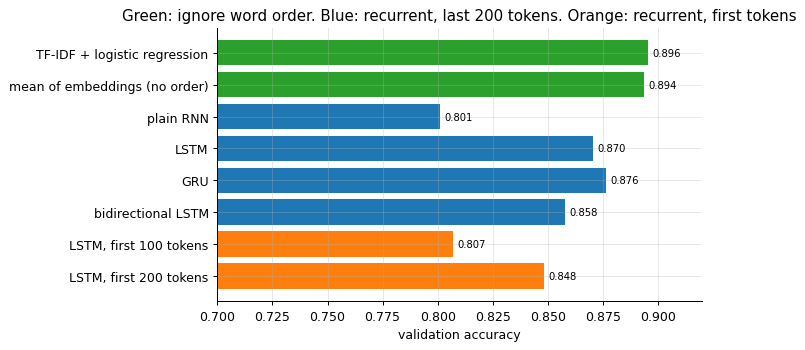

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results)
vals = [results[n][0] for n in names]
colors = ["C2" if ("no order" in n or "TF-IDF" in n) else ("C1" if "first" in n else "C0") for n in names]
ax.barh(names[::-1], vals[::-1], color=colors[::-1])
for yi, v in enumerate(vals[::-1]): ax.text(v + 0.002, yi, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0.7, 0.92); ax.set_xlabel("validation accuracy")
ax.set_title("Green: ignore word order. Blue: recurrent, last 200 tokens. Orange: recurrent, first tokens")
plt.tight_layout(); plt.show()

**What the experiments say.**
- **Plain RNN vs LSTM/GRU.** The plain RNN is far behind. This is the vanishing gradient of section 7 in practice: over 200 steps its gradients cannot connect the output to the words that matter. The gated networks, LSTM and GRU, are close to each other; the GRU is a bit cheaper.
- **Which part of the review to keep.** Keeping the first 100 tokens, as the original lab did, costs several points. Keeping the first 200 is better, and keeping the **last** 200 is better still: the conclusion of a review is more informative than its opening.
- **Bidirectional** does not help here; in this run it is even slightly worse. For a document-level label, the forward LSTM's final state already has read everything. Bidirectional networks matter more for per-word tasks such as tagging.
- **Order-free models are as good as or better than the LSTMs.** The mean-of-embeddings model and TF-IDF are at the top, and they train in a fraction of the time. For sentiment, **which** words appear matters much more than their order. A recurrent network trained from scratch on 20,000 reviews does not have enough data to exploit order beyond that, and its truncation to 200 tokens throws information away.

This is a common and important lesson: always compare against a simple baseline. Sequence models shine when order is essential (translation, speech, time series, text generation) or when they are **pretrained** on huge amounts of text. Pretrained transformers (see *Text_Generation_with_Transformers* and the notes) reach about 95% on IMDB.

## 13. Inside the models

### Word polarity in the mean-of-embeddings model

The mean-of-embeddings model is linear in the average embedding: its logit is $\mathbf{w}^\top\big(\frac{1}{n}\sum_t \mathbf{E}[k_t]\big) + b = \frac{1}{n}\sum_t \mathbf{w}^\top\mathbf{E}[k_t] + b$. So each word $k$ contributes a fixed score $s_k = \mathbf{w}^\top\mathbf{E}[k]$, its learned **polarity**, and the review score is the average polarity of its words.

In [19]:
bag = trained["mean of embeddings (no order)"]
E_bag = bag.embedding.weight.detach().cpu()
polarity = (E_bag @ bag.fc.weight.detach().cpu()[0]).numpy()
freq_ok = counts >= 50                                               # ignore very rare words
idx = np.where(freq_ok)[0]
idx = idx[idx > 3]
order = idx[np.argsort(polarity[idx])]
print("most negative words:", ", ".join(index_word[int(i)] for i in order[:20]))
print("most positive words:", ", ".join(index_word[int(i)] for i in order[::-1][:20]))
for w in ["good", "bad", "not", "boring", "great", "funny", "movie", "the"]:
    print(f"  polarity of {w!r:>9}: {polarity[word_index[w]]:+.2f}")

most negative words: worst, awful, waste, poorly, boring, mess, fails, horrible, terrible, forgettable, disappointing, dull, disappointment, avoid, boredom, worse, lacks, incoherent, pointless, save
most positive words: 7, perfect, refreshing, excellent, wonderfully, today, 8, superb, flawless, touching, rare, amazing, wonderful, highly, subtle, brilliant, awesome, recommended, delicious, enjoyed
  polarity of    'good': +36.68
  polarity of     'bad': -96.09
  polarity of     'not': -25.28
  polarity of  'boring': -135.49
  polarity of   'great': +87.71
  polarity of   'funny': -3.97
  polarity of   'movie': -3.43
  polarity of     'the': +7.33


The model has learned a sentiment lexicon on its own, from labels only. Note the polarity of "not": the model cannot see that "not" flips the next word, so it just gives "not" a mildly negative score. This is precisely the kind of thing a sequence model can, in principle, do better.

### Nearest neighbours in embedding space

Words used in similar ways for the task get similar embedding vectors. We measure similarity with the **cosine** of the angle between vectors, $\cos(\mathbf{u}, \mathbf{v}) = \mathbf{u}^\top\mathbf{v} / (\lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert)$.

In [20]:
def neighbours(word, E, k=8):
    En = F.normalize(E, dim=1)
    sims = En @ En[word_index[word]]
    sims[~torch.tensor(freq_ok)] = -1                                 # only frequent words
    top = sims.argsort(descending=True)[1:k + 1]
    return ", ".join(f"{index_word[int(i)]} ({sims[i]:.2f})" for i in top)

E_lstm = lstm_model.embedding.weight.detach().cpu()
for w in ["excellent", "awful", "boring", "funny"]:
    print(f"{w:>10} | mean-embedding model: {neighbours(w, E_bag)}")
    print(f"{'':>10} | LSTM:                 {neighbours(w, E_lstm)}")

 excellent | mean-embedding model: superb (0.76), 7 (0.75), wonderfully (0.74), amazing (0.73), refreshing (0.73), perfect (0.73), flawless (0.71), rare (0.70)
           | LSTM:                 yet (0.44), discovered (0.41), engage (0.41), seeks (0.40), reporter (0.40), woo (0.39), surprised (0.36), structure (0.36)
     awful | mean-embedding model: worst (0.84), disappointment (0.81), pretentious (0.80), incoherent (0.79), waste (0.79), horrible (0.79), forgettable (0.79), boring (0.78)
           | LSTM:                 arrogant (0.50), cheated (0.45), actual (0.44), sleaze (0.43), griffith (0.40), consists (0.40), happening (0.39), sticks (0.39)
    boring | mean-embedding model: awful (0.78), worst (0.77), fails (0.75), disappointment (0.75), terrible (0.74), incoherent (0.74), dull (0.74), badly (0.73)
           | LSTM:                 dire (0.44), rented (0.41), plain (0.41), consists (0.40), drivel (0.40), pile (0.39), clue (0.39), unlikeable (0.38)
     funny | mean-embeddin

For the mean-of-embeddings model the neighbours are words with the **same sentiment**, not necessarily the same meaning: the only thing these embeddings were trained for is predicting positive versus negative, and in this model the embedding is the only place where that can be stored.

The LSTM's embeddings are much less interpretable. The recurrent layer does part of the work, so the embeddings do not need to line up with sentiment directly.

Look at "funny": its neighbours are nonsense, and almost identical in both models. "Funny" appears in good comedies and in bad films ("unintentionally funny"), so its gradients point both ways and mostly cancel. Its embedding barely moves from its **random initial value**, and both models started from the same random numbers (same seed). An embedding only learns what the task needs. Embeddings trained on a different task, such as predicting the next word on billions of sentences (word2vec, GloVe, language models), capture much richer meaning. Starting from such pretrained embeddings is a standard way to improve a small-data model.

### Reading a review word by word

The LSTM produces a hidden state $\mathbf{h}_t$ after every word. Applying the final linear layer to each $\mathbf{h}_t$ shows what the model "thinks" after reading the first $t$ words: $P(\text{positive} \mid \text{words } 1..t) = \sigma(\mathbf{w}^\top\mathbf{h}_t + b)$.

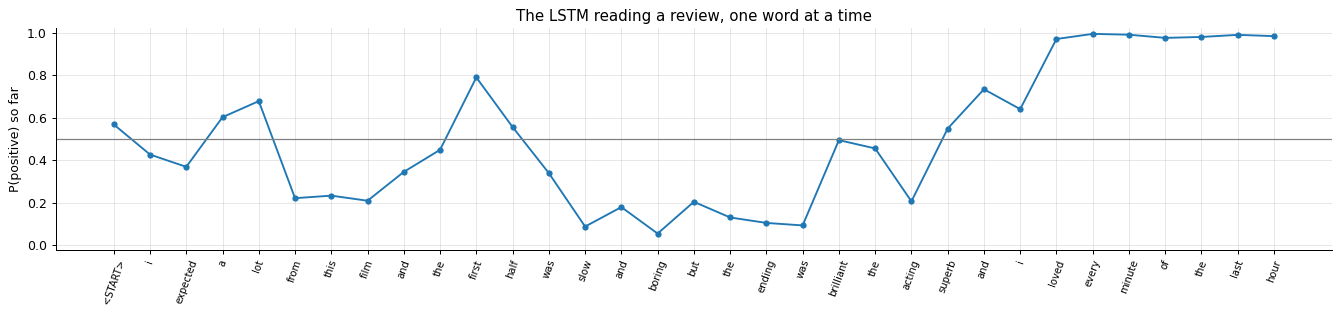

In [21]:
def read_word_by_word(model, ids):
    model.eval()
    with torch.no_grad():
        e = model.embedding(torch.tensor(ids, device=device)[None])
        outputs, _ = model.rnn(e)                                    # (1, t, d_h): every h_t
        return torch.sigmoid(model.fc(outputs)).squeeze().cpu().numpy()

def tokenize(text):
    text = text.lower().replace("<br />", " ")
    return re.findall(r"[a-z0-9']+", text)

def text_to_ids(text):
    return [START] + [word_index.get(w, UNK) if word_index.get(w, UNK) < V else UNK for w in tokenize(text)]

text = ("i expected a lot from this film and the first half was slow and boring . "
        "but the ending was brilliant , the acting superb and i loved every minute of the last hour")
ids = text_to_ids(text)
p_t = read_word_by_word(lstm_model, ids)
words = ["<START>"] + tokenize(text)
fig, ax = plt.subplots(figsize=(15, 3.6))
ax.plot(p_t, "o-", ms=4); ax.axhline(0.5, color="gray", lw=1)
ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=70, fontsize=8)
ax.set_ylim(-0.02, 1.02); ax.set_ylabel("P(positive) so far"); ax.set_title("The LSTM reading a review, one word at a time")
plt.tight_layout(); plt.show()

You can watch the memory at work: the probability reacts to sentiment words, and the verdict can change after a "but". The model was only trained on the final state, so the intermediate values are an approximation, but they show how the hidden state accumulates evidence.

## 14. Your own reviews

To classify new text, it must go through **exactly the same pre-processing** as the training data: lower case, remove punctuation, split into words, map to indices with the same vocabulary (unknown words become `<UNK>`), and add `<START>`. The original version of this lab dropped unknown words and did not add `<START>`, so its inputs looked different from the training data.

We compare the LSTM with the TF-IDF model on a few sentences, including negations, where word order matters.

In [22]:
def predict_lstm(text):
    ids = text_to_ids(text)[-T:]
    x = torch.tensor(ids)[None]
    lstm_model.eval()
    with torch.no_grad():
        return torch.sigmoid(lstm_model(x.to(device), torch.tensor([len(ids)]))).item()

def predict_bow(text):
    return logreg.predict_proba(tfidf.transform([np.array(text_to_ids(text))]))[0, 1]

reviews = [
    "this was a terrible film with too much violence i walked out halfway through",
    "one of the best movies i have seen in years , brilliant acting and a beautiful story",
    "the movie was not good at all",
    "the movie was not bad at all",
    "i did not like it , the story was boring and predictable",
    "at first i thought it would be boring , but it turned out to be wonderful",
    "great actors , great director , great budget , and still a complete waste of time",
]
print(f"{'P(positive)':>12} {'':>8}   review")
print(f"{'LSTM':>12}{'TF-IDF':>9}")
for r in reviews:
    print(f"{predict_lstm(r):>12.3f}{predict_bow(r):>9.3f}   {r}")

 P(positive)            review
        LSTM   TF-IDF
       0.010    0.003   this was a terrible film with too much violence i walked out halfway through
       0.980    0.998   one of the best movies i have seen in years , brilliant acting and a beautiful story
       0.285    0.303   the movie was not good at all
       0.234    0.000   the movie was not bad at all
       0.015    0.000   i did not like it , the story was boring and predictable
       0.460    0.349   at first i thought it would be boring , but it turned out to be wonderful
       0.041    0.859   great actors , great director , great budget , and still a complete waste of time


Try your own sentences. Things to look for:
- Clear reviews are easy for both models.
- **Negation** ("not good", "not bad") is hard for the bag-of-words model by construction: it sees the same words in both sentences. The LSTM can in principle use the order, but it was trained on long reviews where negation is only one signal among many, so it often gets these wrong too.
- Context can help the LSTM: in "great actors, great director, great budget, and still a complete waste of time", the bag-of-words model counts three "great" and predicts positive, while the LSTM gives the final clause the last word.
- Very short sentences are unlike the training reviews (median length above 170 tokens), so both models can be unreliable on them.

## 15. Summary

- Text is a variable-length sequence of tokens. A vocabulary maps tokens to indices, with special tokens for padding, start and unknown words. Word frequencies follow Zipf's law, so a small vocabulary covers most of the text.
- **Always build a baseline.** TF-IDF + logistic regression ignores order and reaches about 89% on IMDB.
- **Embeddings** map indices to learned dense vectors; an embedding is a linear layer on a one-hot vector.
- An **RNN** updates $\mathbf{h}_t = \tanh(\mathbf{W}_{xh}\mathbf{x}_t + \mathbf{W}_{hh}\mathbf{h}_{t-1} + \mathbf{b})$ with shared weights. **BPTT** multiplies one Jacobian per step, so gradients **vanish** or **explode** exponentially with distance. Clip gradients.
- The **LSTM** adds a cell state updated additively, $\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \mathbf{g}_t$, so the gradient along the cell is a product of forget gates and can survive many steps. The GRU is a lighter variant.
- Handle padding correctly: give the lengths to `pack_padded_sequence` (or pad at the start) so the final state is taken after the last real token.
- Truncation is a modelling choice: here the end of a review is more informative than the beginning.
- For sentiment, order-free models are as good as LSTMs trained from scratch. Sequence models pay off when order is essential or when they are pretrained on large corpora, which leads to attention and transformers.

## Exercises

Try each one before opening the answer.

1. **Vanishing gradients.** Explain with the formulas of section 7 why a plain RNN struggles with long sequences, and how the LSTM cell state helps.
2. **Forget gate.** What happens to the cell state when $\mathbf{f}_t \approx \mathbf{0}$, and when $\mathbf{f}_t \approx \mathbf{1}$? Give an intuitive example of what the LSTM might want to forget in a movie review.
3. **Last hidden state.** We classify from $\mathbf{h}_{\text{last}}$ only. What are the limitations? Propose two alternatives.
4. **GRU vs LSTM.** Write the GRU parameter count for $d = d_h = 64$ and compare it with the LSTM. When would you choose one or the other?
5. **Padding side.** Without `pack_padded_sequence`, why does padding at the start fix the problem of section 9, while padding at the end does not?
6. **Improving the LSTM.** Propose three changes that could make the LSTM beat the TF-IDF baseline.

<details>
<summary><b>Answers</b></summary>

**1.** The gradient that reaches $\mathbf{h}_t$ from the loss is multiplied by $\partial\mathbf{h}_k/\partial\mathbf{h}_{k-1} = \text{diag}(1 - \mathbf{h}_k^2)\mathbf{W}_{hh}$ once per step between $t$ and $T$. Its norm is at most $\lVert\mathbf{W}_{hh}\rVert^{T - t}$, which goes to zero exponentially when the factors are below 1. Words far from the end then have almost no effect on the weight updates, and the RNN cannot learn to use them. In the LSTM the cell state is updated additively, and along the cell path $\partial\mathbf{c}_t/\partial\mathbf{c}_{t-1} = \text{diag}(\mathbf{f}_t)$. There is no weight matrix and no $\tanh'$ in the product. If the forget gates are close to 1, the gradient passes through many steps almost unchanged.

**2.** With $\mathbf{f}_t \approx \mathbf{0}$ the old memory is erased: $\mathbf{c}_t \approx \mathbf{i}_t \odot \mathbf{g}_t$ only contains new content. With $\mathbf{f}_t \approx \mathbf{1}$ the memory is kept as it is, and new content is added on top. In a review, after "the first half was dull, but", the LSTM may want to reduce the weight of the negative evidence collected so far, because the verdict that follows the "but" is what counts. It might also forget details of a long plot summary that carry no sentiment.

**3.** $\mathbf{h}_{\text{last}}$ must compress the whole review into $d_h = 64$ numbers, and it is biased towards the last words read, since earlier information has to survive many updates. Alternatives: (a) **pooling over time**, the mean or maximum of all $\mathbf{h}_t$ (each word's state contributes directly); (b) **attention**, a learned weighted average $\sum_t \alpha_t\mathbf{h}_t$ where the weights $\alpha_t$ are computed from the states themselves, so the classifier can focus on the most informative words wherever they are. Attention is the key idea behind transformers.

**4.** A GRU has three blocks instead of four. PyTorch counts $3\,(d_h(d + d_h) + 2d_h) = 3\,(64 \cdot 128 + 128) = 24{,}960$ parameters, against $33{,}280$ for the LSTM, and each step is correspondingly cheaper. In practice they perform similarly; the GRU is a good default when speed or data are limited, and the LSTM's separate memory cell sometimes helps on tasks with very long dependencies. Try both and decide on the validation set.

**5.** Without packing, the network reads all $T$ positions and we take the state at position $T$. With padding at the start, the pads are read **first**, while the memory is still empty, and the real words come last, so the final state is the one after the last real word. The pads still cost some computation and may perturb the initial state slightly, but the effect is small. With padding at the end, the pads come after the review, and the state drifts while reading them, which is what we measured in section 10.

**6.** Some options: use **pretrained word embeddings** (GloVe, word2vec) instead of learning 640,000 embedding parameters from 20,000 reviews; use **longer sequences** or all tokens (the long reviews lost accuracy to truncation); use **mean or max pooling** or **attention** over all hidden states instead of the last one; add **regularisation** (dropout on embeddings, weight decay) since the model overfits after 2 to 3 epochs; or use a **pretrained transformer**, which is what modern systems do and reaches about 95%.

</details>